# The Mathematics of a Retail Trader's Ruin


<a href="https://www.kaggle.com/code/addarm/retail_trader_ruin" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

![The Retail Traders Path to Ruin- OpenAI 2026](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/retail_trader_ruin_banner.png)

Nowadays you open social media and you see posts from trading coaches showing off amazing equity curves. They say, "You can't go wrong with this signal; it has 80% accuracy", "This strategy has massive positive expectancy", or "We have a Sharpe of 6!". The claims may be true, false, or worse: deliberately falsified. 

How would you know and understand what you're looking at?

The truth is, a strategy can have positive expected payoff yet destroy wealth with wrong sizing and risk management, forget to model friction, or you hit a long tail in an unfavorable path. What we can, and should do is design small solvable models that let us separate edge, capital, compounding, and selection, then test the results with simulations. By starting with finite capital and repeating the same trade, we can understand what's profitable and whether it compounds wealth without hitting a capital floor through a sequence of bad events.

Expected payoff and expected log growth are often missing from trading claims, or misrepresented. We will learn both in this article, and what "profitable" means. We'll use some notations in this article, they're mainly to explain, and aren't required to understand the concepts presented here.

## Notebook Setup

In [1]:
from math import comb
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Understand one Trade

Let $Y$ be the payoff from one uncertain trade. A win pays $w>0$ with probability $p$; a loss pays $-\ell$, where $\ell>0$, with the complementary probability $q=1-p$. Writing these outcomes mathematically using the random variable $Y$ (we will reuse them throughout the article):

$$
\mathbb{P}(Y=w)=p,
\qquad
\mathbb{P}(Y=-\ell)=q,
\qquad
p+q=1.
$$

$$
Y_{\text{net}}=Y-c.
$$

And let's not forget $c$, which is the cost of applying the trade!
For a discrete random variable, expectation is defined as the probability-weighted sum of its possible values:

$$
\mathbb{E}[Y]
=
\sum_{y\in\{w,-\ell\}} y\,\mathbb{P}(Y=y).
$$

$$
\mathbb{E}[Y]
=
w\,\mathbb{P}(Y=w)
+
(-\ell)\,\mathbb{P}(Y=-\ell)
=
pw-q\ell.
$$

$$
\mathbb{E}[Y_{\text{net}}]
=
\mathbb{E}[Y-c]
=
pw-q\ell-c.
$$

A high value of $p$ therefore says only that winning outcomes occur frequently. It says nothing by itself about whether the strategy has positive expected payoff. Large losses can make $pw-q\ell<0$, even when $p$ is high. Likewise, a positive gross expectation can become negative once $c$ is included. Keep these points in mind when reading the guru's post. On the same note, a positive value of $\mathbb E[Y]$ says only that one trade has that average payoff. It doesn't yet tell us whether the estimate of $p$ is reliable, whether finite capital survives the path, or whether proportional betting compounds wealth.

We will introduce those objects later.

The code below helps us visualize these simple concepts:

In [2]:
payoff_examples = pd.DataFrame(
    {
        "example": [
            "Frequent small wins",
            "Infrequent large wins",
            "Fair before costs",
        ],
        "p": [0.80, 0.40, 0.501],
        "win_w": [1.0, 2.0, 1.0],
        "loss_l": [5.0, 1.0, 1.0],
        "additive_cost_c": [0.05, 0.05, 0.05],
    }
)
payoff_examples["gross_E_Y"] = payoff_examples["p"] * payoff_examples["win_w"] - (1 - payoff_examples["p"]) * payoff_examples["loss_l"]
payoff_examples["net_E_Y"] = payoff_examples["gross_E_Y"] - payoff_examples["additive_cost_c"]
payoff_examples["gross_sd_Y"] = np.sqrt(
    payoff_examples["p"] * (payoff_examples["win_w"] - payoff_examples["gross_E_Y"]) ** 2
    + (1 - payoff_examples["p"]) * (-payoff_examples["loss_l"] - payoff_examples["gross_E_Y"]) ** 2
)
payoff_examples["gross_annualized_sharpe"] = payoff_examples["gross_E_Y"] / payoff_examples["gross_sd_Y"] * np.sqrt(252)
print(payoff_examples.to_string(index=False))

              example        p    win_w   loss_l  additive_cost_c  gross_E_Y   net_E_Y  gross_sd_Y  gross_annualized_sharpe
  Frequent small wins 0.800000 1.000000 5.000000         0.050000  -0.200000 -0.250000    2.400000                -1.322876
Infrequent large wins 0.400000 2.000000 1.000000         0.050000   0.200000  0.150000    1.469694                 2.160247
    Fair before costs 0.501000 1.000000 1.000000         0.050000   0.002000 -0.048000    0.999998                 0.031749


The first row is the 80% guru signal: four trades out of five are positive, but the strategy still loses money on average because the losing trade is much larger.

The last row shows that even a small postive expectancy can turn negative after costs.

We only know the average payoff of one trade. We still have to ask how well that edge is estimated and what repeated betting does to the wealth curve.

## From Uncertainty to Evidence

We have defined an arithmetic edge Analtytically. But still insufficient to proof that an account survives, we need to ask whether observed data let us estimate that edge reliably.

Let $X$, the outcome of a single trade, follow a Bernoulli distribution with parameter $p$, where $X=1$ denotes a win, $X=0$ denotes a loss, and $p$ is the unknown probability of a win. Here $X$ records a win or loss, unlike $Y$ earlier, which was the monetary payoff, and this is done in alignment with a Bernoulli which just describes a single binary outcome. Therefore

$$
X\sim\operatorname{Bernoulli}(p),
$$

$$
\mathbb{P}(X=1)=p,\qquad \mathbb{P}(X=0)=1-p.
$$

This probability describes the model before the trade which realizes a value, 0 or 1. Let's repeat the trade $n$ times. Write $X_i$ for the outcome of trade $i$ and let $K$ be the total number of wins. If the $X_i$ are independent and identically distributed (IID) Bernoulli variables with the same fixed $p$, then $K$ has a linear expectation, with independence making the variances sum up:

$$
K\sim\operatorname{Binomial}(n,p).
$$

$$
\mathbb E[K]=\sum_{i=1}^{n}\mathbb E[X_i]=np.
$$

$$
\operatorname{Var}(K)=\sum_{i=1}^{n}\operatorname{Var}(X_i)=np(1-p).
$$

Suppose $p=0.55$ and $n=100$. Then $\mathbb E[K]=55$, $\operatorname{Var}(K)=24.75$, and the standard deviation of $K$ is about 4.97 wins (just a square root). But the expectation of 55 is the long-run average across repeated 100-trade samples; it is not a prediction that this sample contains exactly 55 wins.

With that, our observed win frequency is:

$$
\hat p_n=\frac{K}{n}=\frac{1}{n}\sum_{i=1}^{n}X_i.
$$

P hat marks an estimate and $\hat p_n$ is calculated from data. E.g. a run of 7 wins in 10 trades gives $\hat p_{10}=0.7$.

### The Law of Large Numbers and the Central Limit Theorem

For IID Bernoulli trials, the strong Law of Large Numbers (LLN) states

$$
\hat p_n\longrightarrow p \quad\text{as } n\to\infty.
$$

The sample win rate $\hat p_n$ converges - almost surely - to $p$ as $n$ approaches infinity. The LLN describes what happens to one running sample average as more observations are made.

The Central Limit Theorem (CLT) is similar, but focuses on the estimation error. For IID Bernoulli trials with $0<p<1$, the estimation error converges in distribution to a Normal distribution with mean 0 and variance $p(1-p)$:

$$
\sqrt n(\hat p_n-p)\xrightarrow{}N(0,p(1-p)).
$$

as $n$ grows, the distribution of the scaled error approaches that Normal distribution. 

The code below creates figures to visualize these concepts:

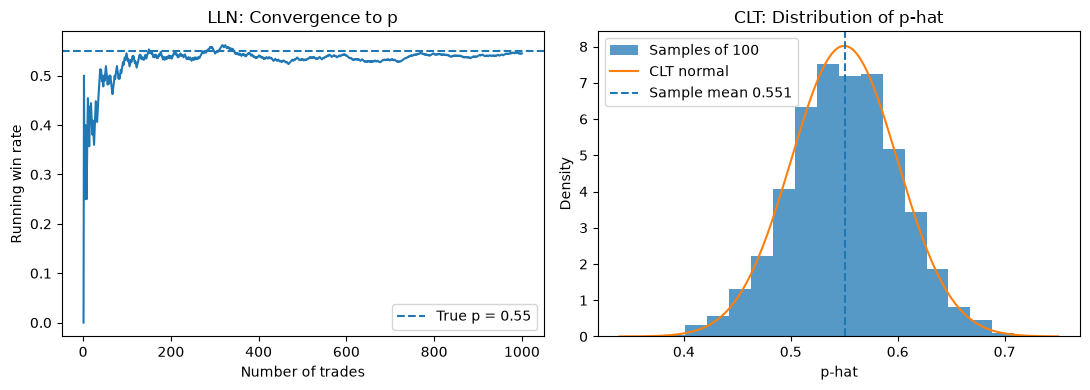

In [3]:
from scipy import stats

true_p = 0.55
lln_rng = np.random.default_rng(42)

n_running = 1_000
running_wins = lln_rng.binomial(1, true_p, n_running)
running_rate = np.cumsum(running_wins) / np.arange(1, n_running + 1)

sample_size = 100
n_samples = 5_000
sample_rates = lln_rng.binomial(sample_size, true_p, n_samples) / sample_size

sample_mean = sample_rates.mean()
sample_sd = sample_rates.std(ddof=1)

grid = np.linspace(sample_rates.min(), sample_rates.max(), 300)

normal_density = stats.norm.pdf(grid, loc=true_p, scale=np.sqrt(true_p * (1 - true_p) / sample_size))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(np.arange(1, n_running + 1), running_rate)
axes[0].axhline(true_p, linestyle="--", label=f"True p = {true_p:.2f}")
axes[0].set(
    title="LLN: Convergence to p",
    xlabel="Number of trades",
    ylabel="Running win rate",
)
axes[0].legend()

axes[1].hist(sample_rates, bins=20, density=True, alpha=0.75, label=f"Samples of {sample_size}")
axes[1].plot(grid, normal_density, label="CLT normal")
axes[1].axvline(sample_mean, linestyle="--", label=f"Sample mean {sample_mean:.3f}")
axes[1].set(
    title="CLT: Distribution of p-hat",
    xlabel="p-hat",
    ylabel="Density",
)
axes[1].legend()

plt.tight_layout()
plt.show()

In the left plot, we can see a running win rate and how it wanders at small sample sizes before settling near $p$. On the right, repeated 100-trade samples produce different estimates around the same $p$.


### Markets Are Different!

The elementary results above assume independent observations drawn from one stable distribution. Financial observations may depend on each other, and their distribution may change over time, or in reaction to players themselves.

A trading process may exhibit serial dependence, volatility clustering, structural breaks, regime changes, or changing conditional distributions. Market participants can also react to signals and strategies, so the data-generating process can shift when a strategy is deployed.

The classical CLT stated above also requires finite variance. Financial returns can be heavy-tailed, making variance harder to estimate reliably and requiring careful checks of the assumptions.

This does **not** mean that the LLN and CLT do not apply to markets. Generalized versions exist for dependent and non-identically distributed processes. It means that a theorem supports a trading claim only when its assumptions and conditions are satisfied (Cont, 2001).

Let's take a toy example, suppose the win probability changes halfway through the sample:

$$
p_t=
\begin{cases}
0.55, & t\le500,\\
0.45, & t>500.
\end{cases}
$$

The code below will help us see what a single running estimate of $p$ means when the distribution, and therefore the quantity being estimated, is itself changing.

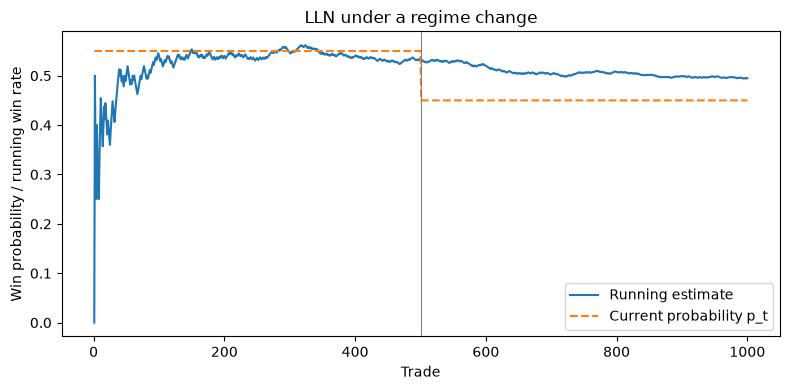

In [4]:
regime_rng = np.random.default_rng(42)
regime_p = np.r_[np.full(500, 0.55), np.full(500, 0.45)]
regime_wins = regime_rng.random(regime_p.size) < regime_p
regime_running_rate = np.cumsum(regime_wins) / np.arange(1, regime_p.size + 1)
trade_index = np.arange(1, regime_p.size + 1)

plt.figure(figsize=(8, 4))
plt.plot(trade_index, regime_running_rate, label="Running estimate")
plt.plot(trade_index, regime_p, linestyle="--", label="Current probability p_t")
plt.axvline(500.5, color="grey", linewidth=0.8)
plt.xlabel("Trade")
plt.ylabel("Win probability / running win rate")
plt.title("LLN under a regime change")
plt.legend()
plt.tight_layout()
plt.show()

The first half estimates a probability near 0.55 and the second half near 0.45, while the full-sample rate is close to 0.50. That pooled number is faithful to the full-sample average, but it doesn't describe the current regime. A posted hit rate can therefore hide a change in the process that generated it.

## Edge is Estimated

The payoff calculation treated $p$, $w$, $\ell$, and $c$ as known. In the real market landscape, they are estimated from limited data.

Suppose we observe $n$ trades and estimate the win probability, assuming an IID Bernoulli model:

$$
\hat p_n=\frac{\text{number of wins}}{n}.
$$

$$
\mathbb E[\hat p_n]=p,
\qquad
\operatorname{Var}(\hat p_n)=\frac{p(1-p)}{n}.
$$

$$
SE(\hat p_n)=\sqrt{\frac{p(1-p)}{n}}.
$$

The standard error tells us how much the estimated win rate typically varies across repeated samples. Uncertainty therefore falls slowly. Ten times more observations reduces the standard error by only about $\sqrt{10}\approx3.16.$

So a 55% observed win rate after 100 trades is much weaker evidence than a 55% observed win rate after 5,000 trades. Because the true $p$ is unknown, we can also report a 95% confidence interval (CI) around the observed win rate.

The simplest CI version is the Wald interval:

$$
\hat p_n
\pm
1.96\sqrt{\frac{\hat p_n(1-\hat p_n)}{n}}.
$$

A more reliable alternative for smaller samples is the Wilson interval:

$$
\frac{
\hat p_n+\frac{z^2}{2n}
\pm
z\sqrt{
\frac{\hat p_n(1-\hat p_n)}{n}
+
\frac{z^2}{4n^2}
}
}{
1+\frac{z^2}{n}
}.
$$

For example, with 55 wins from 100 trades, $\hat p_{100}=0.55$, the Wilson interval is approximately $[0.452,0.644]$, while the Wald interval is approximately $[0.452,0.648]$.

The interval shows the uncertainty around our estimate. If we repeated the experiment many times and calculated a 95% confidence interval each time, about 95% of those intervals would contain the true $p$.

The code uses the Wilson interval because its coverage is generally more reliable than the Wald interval for small samples or probabilities close to 0 or 1.

In [5]:
def wilson_interval(successes, trials, z=1.959963984540054):
    estimate = successes / trials
    denominator = 1 + z**2 / trials
    center = (estimate + z**2 / (2 * trials)) / denominator
    half_width = z / denominator * np.sqrt(estimate * (1 - estimate) / trials + z**2 / (4 * trials**2))
    return center - half_width, center + half_width


edge_uncertainty_rows = []
for trials in [100, 1_000, 5_000]:
    successes = int(0.55 * trials)
    lower, upper = wilson_interval(successes, trials)
    edge_uncertainty_rows.append((trials, successes / trials, lower, upper, lower > 0.5))

edge_uncertainty = pd.DataFrame(
    edge_uncertainty_rows,
    columns=["trades_n", "observed_hit_rate", "wilson_95_lower", "wilson_95_upper", "excludes_0_50"],
)
print(edge_uncertainty.to_string(index=False))

 trades_n  observed_hit_rate  wilson_95_lower  wilson_95_upper  excludes_0_50
      100           0.550000         0.452446         0.643855          False
     1000           0.550000         0.519033         0.580585           True
     5000           0.550000         0.536177         0.563746           True


The same observed hit rate can mean very different things depending on the number of trades.

With 100 trades, the interval is wide. A benchmark rate of 50% is still consistent with the data. With 1,000 and 5,000 trades, the intervals are narrower and no longer contain 50%, as the we get closer to the true mean.

The observed hit rate stayed at 55%, but our uncertainty about the true $p$ became much smaller as the sample grew. In trading, we cannot observe the true edge directly, so confidence intervals matter, especially when the sample is small.

There are other tools for assessing $p$, including statistical significance tests based on an alpha level, but confidence intervals make the size and uncertainty of the estimated edge easier to see for us.

## From Edge to Survival

So far we have focused on whether a trade has positive expected value and whether we can estimate that edge. Now we hold $p$ fixed and known so that we can isolate the effect of finite capital and the path taken by realized wealth.

Let $W_t$ denote wealth after $t$ trades. We distinguish three ideas:

- **Literal ruin:** wealth reaches or crosses zero, $W_t\le0$.
- **Economic ruin:** wealth falls below some floor $W_{\min}>0$, so $W_t\le W_{\min}$.
- **Asymptotic decay:** wealth approaches zero over time, $W_t\to0$ as $t\to\infty$. AKA, the death by thousand cuts.

These are different. An account can remain positive but become too small to continue trading, a common pattern in leveraged trading.

The wealth process uses the same payoff variable $Y$ that we introduced at the start:

$$
W_{t+1}=W_t+Y_{t+1},
$$

$$
W_{t+1}=
\begin{cases}
W_t+w, & \text{with probability }p,\\
W_t-\ell, & \text{with probability }q=1-p.
\end{cases}
$$

Gambler's ruin is a hitting-probability question for this wealth process. Given $\inf$ means the earliest trade, let

$$
\tau_0=\inf\{t\ge0:W_t\le0\},
\qquad
\tau_N=\inf\{t\ge0:W_t\ge N\}.
$$

$$
P(i)=\mathbb{P}(\tau_N<\tau_0\mid W_0=i),
$$

the probability of reaching the upper boundary before ruin from initial wealth $i$. A first-step argument gives the general recurrence with boundary convention

$$
P(i)=pP(i+w)+qP(i-\ell),
$$

$$
P(i)=0\quad\text{for }i\le0,
\qquad
P(i)=1\quad\text{for }i\ge N.
$$

The inequalities count an overshoot as hitting the corresponding boundary. For arbitrary or unequal $w$ and $\ell$, this recurrence is generally more complicated than the familiar formula below and may need a numerical solution or simulation. The ruin framework therefore still works with arbitrary payoffs; what we lose is the simple classical closed form.

To obtain the classical closed-form result, we  consider the simple case $w=\ell=1$. This changes the general payoff model to fixed unit steps, so wealth moves additively by exactly one unit on every trade. In this special case the process hits 0 or $N$ exactly, and we write $P_i=P(i)$.

Suppose we start with 20 units. After one trade, only two things can happen: $20\to21$ with probability $p$, or $20\to19$ with probability $q$. Therefore,

$$
P_{20}=pP_{21}+qP_{19}.
$$

$$
P_i=pP_{i+1}+qP_{i-1}.
$$


The probability of eventual success from 20 is the probability-weighted average of the success probabilities from the two states we can reach next. The same argument works for any interior state, with boundaries $P_0=0$ and $P_N=1$.

Given the $P_i$ formula above, this means that for any current capital level $i$, we have a recurrence relation: the probability of eventually reaching the target from $i$ depends on what happens after the next trade. More precisely, there are two cases.

If the game is fair, the recurrence is simple:

$$
p=q=0.5,
$$

$$
P_i=\frac12P_{i+1}+\frac12P_{i-1}.
$$

$$
P_i=\frac{i}{N}.
$$

This means $P_i$ changes by the same amount as we move from one capital level to the next, because its linear $y = a + bx$. 

If the game is biased ($p\ne q$), there is no linearity. Solving the same recurrence gives

$$
P_i=
\frac{1-(q/p)^i}
{1-(q/p)^N}.
$$


$$
P_i=
\begin{cases}
\dfrac{i}{N}, & p=\dfrac12,\\[8pt]
\dfrac{1-(q/p)^i}{1-(q/p)^N}, & p\ne\dfrac12.
\end{cases}
$$

Now consider the fair case. Suppose we start with 20 units and stop when we either reach 0 or 100:

$$
i=20,
\qquad
N=100.
$$

$$
P_{20}=\frac{20}{100}=0.20.
$$

the probability of reaching 100 before ruin is $20\%$. This does not contradict the 50% probability of winning each trade. The 50% refers only to the **next trade**. The 20% refers to the probability of surviving the entire path from 20 to 100 before ever hitting 0.

Obvsiously in a fair random walk, starting closer to ruin than to the target makes ruin more likely to be reached first.

In [6]:
def hit_target_probability(start, target, p):
    if start <= 0:
        return 0.0
    if start >= target:
        return 1.0
    if p == 0:
        return 0.0
    if p == 1:
        return 1.0
    if p == 0.5:
        return start / target

    q = 1 - p
    ratio = q / p

    return (1 - ratio**start) / (1 - ratio**target)


target_examples = pd.DataFrame({"p": [0.48, 0.50, 0.52]})
target_examples["start_i"] = 20
target_examples["target_N"] = 100
target_examples["P_hit_100_before_0"] = target_examples["p"].map(lambda p: hit_target_probability(20, 100, p))

print(target_examples.to_string(index=False))


       p  start_i  target_N  P_hit_100_before_0
0.480000       20       100            0.001322
0.500000       20       100            0.200000
0.520000       20       100            0.798543


The code shows that the probability of reaching the target depends on the whole sequence of future trades, not just the next trade. When $p<0.5$, losses are slightly more likely than wins, so over many steps the process tends to drift toward 0. When $p>0.5$, wins are slightly more likely, so the process tends to drift toward 100. That is why changing the win probability from 48% to 52% produces such a large change in the probability of reaching the target before ruin.

## Markov Chains for the Same Process

The same fixed-unit wealth process can also be represented as a **Markov chain**. The possible wealth states are

$$
\mathcal S=\{0,1,\ldots,N\}.
$$

If current wealth is $i$, the next trade moves it to $i+1$ with probability $p$, or to $i-1$ with probability $q=1-p$:

$$
\mathbb{P}(W_{t+1}=i+1\mid W_t=i)=p,
$$

$$
\mathbb{P}(W_{t+1}=i-1\mid W_t=i)=q.
$$

This simplified wealth process is Markov because, under the model assumptions, the distribution of the next state depends only on the current state:

$$
\mathbb{P}(W_{t+1}=j\mid W_t,W_{t-1},\ldots,W_0)
=
\mathbb{P}(W_{t+1}=j\mid W_t).
$$

Real financial markets need not satisfy this simple Markov structure and can all make the relevant state richer than current wealth alone. Here, states 0 and $N$ are **absorbing states** because the experiment stops once either boundary is reached. The rest are transient states.

For a small example such as $N=4$, we can describe all possible one-step movements with a transition matrix. If $Q$ contains only the transitions between transient states, then the fundamental matrix $F$ is

$$
F=(I-Q)^{-1}.
$$

Its entries tell us how often we expect to visit each transient state before eventually reaching either boundary. If $R$ contains the probabilities of moving from transient states into the absorbing states, then $B=FR$ gives the probability of eventually being absorbed at each boundary. We can also calculate

$$
\mathbf d=F\mathbf 1,
$$

which gives the expected number of steps before wealth reaches either $0$ or $N$.

In [7]:
def absorbing_chain_summary(target, p):
    q = 1 - p
    states = np.arange(target + 1)

    P = np.zeros((target + 1, target + 1))

    P[0, 0] = 1
    P[target, target] = 1

    for i in range(1, target):
        P[i, i + 1] = p
        P[i, i - 1] = q

    Q = P[1:target, 1:target]
    R = P[1:target][:, [0, target]]

    N = np.linalg.inv(np.eye(target - 1) - Q)

    absorption_probabilities = N @ R
    expected_steps = N @ np.ones(target - 1)

    summary = pd.DataFrame(
        {
            "start": states[1:target],
            "P_hit_0": absorption_probabilities[:, 0],
            f"P_hit_{target}": absorption_probabilities[:, 1],
            "expected_steps": expected_steps,
        }
    )

    return P, Q, R, N, summary


P, Q, R, N, summary = absorbing_chain_summary(target=4, p=0.5)

print("Full transition matrix P:")
print(pd.DataFrame(P, index=range(5), columns=range(5)))

print("\nTransient-state matrix Q:")
print(pd.DataFrame(Q, index=[1, 2, 3], columns=[1, 2, 3]))

print("\nFundamental matrix N:")
print(pd.DataFrame(N, index=[1, 2, 3], columns=[1, 2, 3]))

print("\nSummary:")
print(summary)


Full transition matrix P:
         0        1        2        3        4
0 1.000000 0.000000 0.000000 0.000000 0.000000
1 0.500000 0.000000 0.500000 0.000000 0.000000
2 0.000000 0.500000 0.000000 0.500000 0.000000
3 0.000000 0.000000 0.500000 0.000000 0.500000
4 0.000000 0.000000 0.000000 0.000000 1.000000

Transient-state matrix Q:
         1        2        3
1 0.000000 0.500000 0.000000
2 0.500000 0.000000 0.500000
3 0.000000 0.500000 0.000000

Fundamental matrix N:
         1        2        3
1 1.500000 1.000000 0.500000
2 1.000000 2.000000 1.000000
3 0.500000 1.000000 1.500000

Summary:
   start  P_hit_0  P_hit_4  expected_steps
0      1 0.750000 0.250000        3.000000
1      2 0.500000 0.500000        4.000000
2      3 0.250000 0.750000        3.000000


The code above matches the earlier recurrence but with matrices. Starting from state 2, the middle row of $F$ is $(1,2,1)$.

So before reaching 0 or 4, the process expects about one visit to state 1, two visits to state 2, and one visit to state 3. That gives an expected stopping time of four trades.

The absorption table also gives

$$
\mathbb{P}(\text{hit }0)=0.5,
\qquad
\mathbb{P}(\text{hit }4)=0.5.
$$

This is exactly the fair-game result: $P_i=\frac{i}{N}$ and in a fair game its expected next value equals its current value. This property is called a **martingale**.

The image below is a generalized markov chain for this problem:

![MC - OpenAI 2026](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/markov_chain_ruin.png)

## Monte Carlo for Validation

Monte Carlo simulation gives us a way to check whether our code reproduces the theoretical result.

We simulate the same fixed-unit wealth process many times and record how often the target is reached before ruin. Each Monte Carlo path produces a Bernoulli outcome: whether it reached the target or not.

If we run $M$ simulations, then the estimated target-hit probability is

$$
\hat P_{MC}
=
\frac{\text{sims that reach the target}}
{M}.
$$


Because the simulation is random, this estimate will vary slightly each time. The Monte Carlo standard error follows the binomial formula because it is based on Bernoulli outcomesand therefor, uncertainty falls at roughly $\frac{1}{\sqrt M}$. So cutting the simulation error in half requires approximately four times as many simulated paths.

In [8]:
def simulate_absorption(n_paths, start, target, p, max_steps, rng):
    wealth = np.full(n_paths, start, dtype=np.int32)
    steps = np.zeros(n_paths, dtype=np.int32)
    active = np.ones(n_paths, dtype=bool)

    for _ in range(max_steps):
        idx = np.flatnonzero(active)

        if idx.size == 0:
            break

        wealth[idx] += np.where(rng.random(idx.size) < p, 1, -1)
        steps[idx] += 1

        active[idx] = (wealth[idx] > 0) & (wealth[idx] < target)

    return wealth, steps, active


rows = []
n_paths = 20_000
absorption_rng = np.random.default_rng(42)

for p in [0.48, 0.50, 0.52]:
    terminal, steps, active = simulate_absorption(
        n_paths,
        start=20,
        target=100,
        p=p,
        max_steps=100_000,
        rng=absorption_rng,
    )

    hits = np.sum(terminal == 100)
    simulated = hits / n_paths
    exact = hit_target_probability(20, 100, p)

    lower, upper = wilson_interval(
        hits,
        n_paths,
        z=3.290527,
    )

    rows.append(
        {
            "p": p,
            "exact": exact,
            "simulated": simulated,
            "mc_se": np.sqrt(simulated * (1 - simulated) / n_paths),
            "wilson_99_9_lower": lower,
            "wilson_99_9_upper": upper,
            "unresolved": active.sum(),
            "mean_steps": steps.mean(),
        }
    )

absorption_check = pd.DataFrame(rows)

assert absorption_check["unresolved"].sum() == 0
print(absorption_check)

         p    exact  simulated    mc_se  wilson_99_9_lower  wilson_99_9_upper  \
0 0.480000 0.001322   0.001600 0.000283           0.000902           0.002838   
1 0.500000 0.200000   0.197850 0.002817           0.188745           0.207282   
2 0.520000 0.798543   0.803000 0.002812           0.793583           0.812089   

   unresolved   mean_steps  
0           0   502.032200  
1           0 1,595.775100  
2           0 1,505.665900  


The simulation is close to the exact probability in all three cases, which is what we wanted to verify.

A value of $p<0.5$ does not mean every path reaches zero first. It only makes downward moves more likely. Because the process still has two boundaries, some paths can reach the upper one before ruin.

If we remove the upper boundary, we are solving a different problem.

## Remove the Upper Target

Now remove the upper target and suppose the trader keeps trading indefinitely, or to the moon as they say. Let $h_i$ be the probability of **ever reaching zero** when starting with capital $i$.

If $p\le0.5$, there is no upward advantage. Given enough time, ruin occurs with probability 1.

If $p>0.5$, the process has an upward drift, so ruin is no longer certain. The ruin probability becomes

$$
h_i=\left(\frac{q}{p}\right)^i,
\qquad q=1-p.
$$

Every extra unit of starting capital moves the trader one step farther from zero, and each extra step multiplies the ruin probability by the same factor: $\frac{q}{p}$.

For example:

$$
p=0.52,
\qquad
q=0.48,
$$

$$
\frac{q}{p}\approx0.923.
$$

$$
h_i=0.923^i.
$$

Starting with one unit gives ruin probability about $92.3\%$. Starting with two units gives $0.923^2$, and starting with ten units gives $0.923^{10}$.

Putting both cases together:

$$
h_i=
\begin{cases}
1, & p\le\dfrac12,\\[6pt]
\left(\dfrac{q}{p}\right)^i, & p>\dfrac12.
\end{cases}
$$

A positive edge therefore reduces the probability of eventual ruin, but finite starting capital still leaves some chance of reaching zero.

In [9]:
def eventual_ruin_probability(start, p):
    if p <= 0.5:
        return 1.0
    return ((1 - p) / p) ** start


eventual_ruin = pd.DataFrame({"p": [0.48, 0.50, 0.52, 0.55]})
eventual_ruin["start_i"] = 20
eventual_ruin["P_eventual_hit_0"] = eventual_ruin["p"].map(lambda p: eventual_ruin_probability(20, p))
print(eventual_ruin.to_string(index=False))

       p  start_i  P_eventual_hit_0
0.480000       20          1.000000
0.500000       20          1.000000
0.520000       20          0.201724
0.550000       20          0.018072


At $p=0.52$, one trade has positive expectation, yet capital of 20 still has about a one-in-five chance of eventual literal ruin in this fixed-step game. That's because the horizon also matters. Ruin over the next 100 trades and ruin at any time in the future are different probabilities.

## How Long Can You Trade?

Yes, we do want to know how long we can trade. Anybody can get a lucky trade, including the guru, but who knows whether that luck will last a year or ten years?

For the same fixed-unit process, let $T=\min(\tau_0,\tau_N)$ be the time to either boundary and define

$$
D_i=\mathbb E[T\mid W_0=i].
$$



$$
D_i=1+pD_{i+1}+qD_{i-1},
\qquad
D_0=D_N=0.
$$

A first-step argument gives $D_i$ is the expected number of trades remaining when current wealth is $i$. One trade happens immediately. After that, wealth moves to $i+1$ with probability $p$ or to $i-1$ with probability $q$. The $1$ is the trade we take now; the rest is the expected number of trades still remaining afterward.

For a fair game, $p=q=0.5$, the result simplifies to

$$
\mathbb E[T\mid W_0=i]=i(N-i).
$$

So if we start at $i=20$ with boundaries at 0 and 100,

$$
\mathbb E[T\mid W_0=20]
=
20(100-20)
=
1{,}600.
$$

The process is therefore expected to hit either 0 or 100 after 1,600 trades.

For a biased game, $p\ne0.5$, the corresponding result is

$$
\mathbb E[T\mid W_0=i]
=
\frac{i-NP_i}{q-p},
$$

where $P_i$ is the probability of reaching $N$ before 0 that we calculated earlier. This is the expected time to either boundary, not the expected time to ruin specifically.

We can use Monte Carlo simulation to check these values:

In [10]:
def simulate_absorption_time(n_paths, start, target, p, max_steps, rng):
    wealth = np.full(n_paths, start, dtype=np.int32)
    steps = np.zeros(n_paths, dtype=np.int32)
    active = np.ones(n_paths, dtype=bool)

    for _ in range(max_steps):
        idx = np.flatnonzero(active)

        if idx.size == 0:
            break

        wealth[idx] += np.where(rng.random(idx.size) < p, 1, -1)
        steps[idx] += 1
        active[idx] = (wealth[idx] > 0) & (wealth[idx] < target)

    return steps, active


def expected_absorption_steps(start, target, p):
    if p == 0.5:
        return start * (target - start)
    target_probability = hit_target_probability(start, target, p)
    return (start - target * target_probability) / ((1 - p) - p)


rows = []
duration_rng = np.random.default_rng(42)

for p in [0.48, 0.50, 0.52]:
    steps, active = simulate_absorption_time(
        n_paths=20_000,
        start=20,
        target=100,
        p=p,
        max_steps=100_000,
        rng=duration_rng,
    )

    rows.append(
        {
            "p": p,
            "theoretical_mean_steps": expected_absorption_steps(20, 100, p),
            "monte_carlo_mean_steps": steps.mean(),
            "unresolved": active.sum(),
        }
    )

duration_mc = pd.DataFrame(rows)

assert duration_mc["unresolved"].sum() == 0
print(duration_mc.to_string(index=False))

       p  theoretical_mean_steps  monte_carlo_mean_steps  unresolved
0.480000              496.694253              502.032200           0
0.500000            1,600.000000            1,595.775100           0
0.520000            1,496.356496            1,505.665900           0


The simulation is close to the closed-form expected stopping time in all three cases.

With $p=0.48$, the downward drift pushes wealth toward 0 relatively quickly, giving a theoretical mean of about 497 trades. With $p=0.50$, there is no drift, so wealth wanders back and forth for much longer and the theoretical mean is 1,600 trades. With $p=0.52$, the upward drift moves many paths away from ruin and toward the distant target at 100, giving a theoretical mean of about 1,496 trades.

The unresolved count is zero in every case, so all simulated paths reached either 0 or 100 within the allowed simulation horizon.

## Put Costs in the Equation

Let's return to the payoff variable $Y$ and add an additive cost $c$ per trade. For the even-money case $w=\ell=1$,

$$
\mathbb{E}[Y_{\text{net}}]
=
p(1-c)+(1-p)(-1-c)
=
2p-1-c.
$$


$$
p_{\text{break-even}}=\frac{1+c}{2}.
$$

Break-even means setting the above expectation to zero. So a cost of 0.10 payoff units requires a 55% win rate just to reach zero arithmetic expectation.

In [11]:
additive_costs = np.array([0.00, 0.01, 0.02, 0.05, 0.10, 0.20])
break_even = pd.DataFrame(
    {
        "additive_cost_c": additive_costs,
        "break_even_p": (1 + additive_costs) / 2,
    }
)
assert np.isclose(break_even.loc[break_even["additive_cost_c"].eq(0.10), "break_even_p"].iloc[0], 0.55)
print(break_even.to_string(index=False))

 additive_cost_c  break_even_p
        0.000000      0.500000
        0.010000      0.505000
        0.020000      0.510000
        0.050000      0.525000
        0.100000      0.550000
        0.200000      0.600000


Every 0.01 of additive cost raises the break-even hit rate by 0.005. A cost of 0.05 moves break-even from 50% to 52.5%; a cost of 0.10 moves it to 55%.

It is still a one-trade hurdle. Once position size scales with wealth, compounding changes the criterion.

## Compound your Capital

Fixed-unit gambler's ruin changed wealth additively by $+1$ or $-1$. Proportional betting changes wealth multiplicatively because the amount exposed depends on current wealth. This simple model answers whether repeated proportional exposure compounds wealth.

Suppose $W_t$ is wealth immediately before trade $t+1$, $f$ is the fraction of current wealth exposed, and $R_{t+1}$ is the return per unit exposed. Then

$$
W_{t+1}=W_t(1+fR_{t+1}),
$$

$$
1+fR_{t+1}>0
$$

$$
W_n=W_0\prod_{t=1}^{n}(1+fR_t)
$$. 

Each trade acts on the wealth left by the previous one. That is why a 50% gain followed by a 50% loss isn't flat $1.5\times0.5=0.75$. The two arithmetic returns average to zero, but wealth ends 25% lower. Arithmetic averaging and compounding are different operations.

In [12]:
return_pairs = pd.DataFrame(
    {
        "up_return": [0.10, 0.25, 0.50, 1.00],
        "down_return": [-0.10, -0.25, -0.50, -0.50],
    }
)
return_pairs["arithmetic_mean"] = return_pairs[["up_return", "down_return"]].mean(axis=1)
return_pairs["two_period_multiplier"] = (1 + return_pairs["up_return"]) * (1 + return_pairs["down_return"])
return_pairs["mean_log_growth"] = (np.log1p(return_pairs["up_return"]) + np.log1p(return_pairs["down_return"])) / 2
print(return_pairs.to_string(index=False))

 up_return  down_return  arithmetic_mean  two_period_multiplier  mean_log_growth
  0.100000    -0.100000         0.000000               0.990000        -0.005025
  0.250000    -0.250000         0.000000               0.937500        -0.032269
  0.500000    -0.500000         0.000000               0.750000        -0.143841
  1.000000    -0.500000         0.250000               1.000000         0.000000


The gap widens with larger swings. Alternating $+10\%$ and $-10\%$ leaves 99% of starting wealth. Alternating $+50\%$ and $-50\%$ leaves only 75%.

The last row goes the other way: $+100\%$ followed by $-50\%$ returns wealth exactly to its starting level even though the arithmetic mean is positive.

We need a measure that turns multiplicative wealth changes into something additive across time. Logs do that.

## Volatility Drags on Compound Growth

Volatility matters because, as we saw in the previou seciton, gains and losses do not compound symmetrically. Suppose we start with 100. A 10% gain followed by a 10% loss gives $100(1.10)(0.90)=99$. The average return across the two periods is 0%, yet wealth still falls by 1%. After losing that 10%, we need more than a 10% gain to recover: $90\times1.1111\approx100$.

This gap between arithmetic and compound growth is commonly called volatility drag.

We measure long-run compound growth using log returns:

$$
g(f)=\mathbb E[\log(1+fR)].
$$

$$
\mathbb{E}[Y]>0
$$


$$
\mathbb{E}[\log(1+fR)]>0
$$

The last expectancy says that repeated proportional exposure has positive expected log growth. One can hold while the other fails.

For relatively small returns and full exposure, expected log growth is approximately

$$
g(1)\approx\mu-\frac12\sigma^2,
$$

or the average return minus the volatility penalty, where $\mu$ is the average return and $\sigma^2$ is the return variance. Therefore, a higher average return helps growth, but higher volatility reduces it. Two strategies with the same average return can therefore produce very different long-run wealth if one is much more volatile.

If we scale exposure by $f$, the approximation becomes

$$
g(f)\approx f\mu-\frac12f^2\sigma^2.
$$

The return contribution grows roughly with $f$, while the volatility penalty grows with $f^2$. This is why increasing leverage can eventually reduce, rather than increase, long-run compound growth.

## How Much to Risk?

Suppose the trade really has an edge and we validate it using the methods above. The next question is how much of our capital to risk.

Return to the even-money bet. Let $f$ be the fraction of current wealth risked on each trade, with $0\le f<1$. If we win, wealth is multiplied by $1+f$. If we lose, wealth is multiplied by $1-f$.

With win probability $p$ and loss probability $q=1-p$, expected log growth per trade is

$$
g(f)=p\log(1+f)+q\log(1-f).
$$

The **Kelly criterion** chooses the fraction $f$ that maximizes this long-run growth rate, at the maximum, $g'(f)=0$. (Kelly, 1956):

$$
g'(f)=\frac{p}{1+f}-\frac{q}{1-f}.
$$

$$
\frac{p}{1+f}=\frac{q}{1-f},
$$

$$
f^*=p-q=2p-1.
$$

Therefore, for an even-money bet when we do not take a negative position, $f_{\mathrm{Kelly}}=\max(0,2p-1)$ For example, if $p=0.55$, then

$$
f_{\mathrm{Kelly}}
=
2(0.55)-1
=
0.10.
$$

So the Kelly fraction is 10% of current wealth per trade. But there's a catch: this assumes that the true $p$ is known. In practice, we estimate $p$. Suppose $\hat p=0.55$. Putting that estimate in the criterion gives

$$
\hat f=2\hat p-1=0.10.
$$

But don't forget our earlier confidence interval. It showed that the true $p$ could still be close to $0.50$, where the Kelly fraction would be $f_{\mathrm{Kelly}}=0$.

So uncertainty in the estimated edge becomes uncertainty in the position size. Kelly also does not mean "risk as much as possible". For $p=0.55$, expected log growth eventually falls back to zero at about $f\approx0.199$. Beyond that point, the trade still has positive arithmetic expectancy, but the position is so large that expected log growth becomes negative. A positive edge can never justify unlimited exposure, risk management is required!

Let's look at it in code:

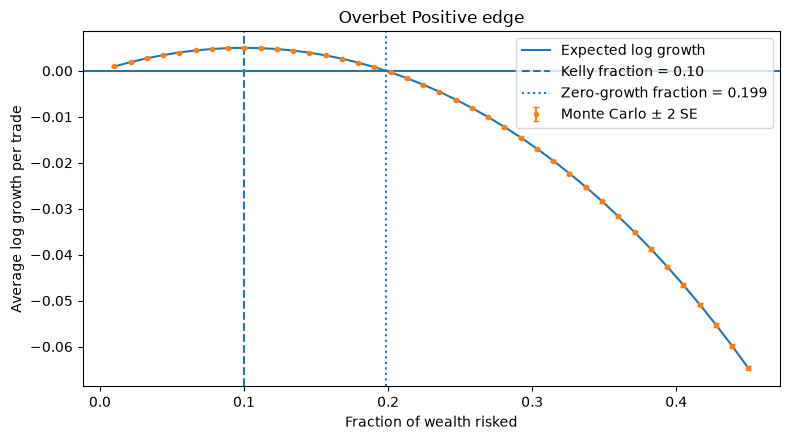

In [13]:
import numpy as np
import matplotlib.pyplot as plt


def expected_log_growth(f, p):
    q = 1 - p
    return p * np.log(1 + f) + q * np.log(1 - f)


def find_zero_growth_fraction(p, lower, upper, iterations=60):
    for _ in range(iterations):
        midpoint = (lower + upper) / 2
        growth = expected_log_growth(midpoint, p)

        if growth > 0:
            lower = midpoint
        else:
            upper = midpoint

    return (lower + upper) / 2


def simulate_log_growth(f, p, n_paths=5000, n_steps=1000, seed=42):
    rng = np.random.default_rng(seed)

    wins = rng.binomial(n_steps, p, size=n_paths)
    losses = n_steps - wins

    path_growth = (wins * np.log(1 + f) + losses * np.log(1 - f)) / n_steps

    mean = path_growth.mean()
    se = path_growth.std(ddof=1) / np.sqrt(n_paths)

    return mean, se


p = 0.55

kelly_fraction = 2 * p - 1

zero_growth_fraction = find_zero_growth_fraction(
    p=p,
    lower=kelly_fraction,
    upper=0.95,
)

fractions = np.linspace(0.01, 0.45, 40)

theoretical_growth = np.array([expected_log_growth(f, p) for f in fractions])

mc_growth = []
mc_se = []

for f in fractions:
    mean, se = simulate_log_growth(
        f=f,
        p=p,
        n_paths=5000,
        n_steps=1000,
        seed=42,
    )

    mc_growth.append(mean)
    mc_se.append(se)

mc_growth = np.array(mc_growth)
mc_se = np.array(mc_se)

plt.figure(figsize=(8, 4.5))

plt.plot(
    fractions,
    theoretical_growth,
    label="Expected log growth",
)

plt.errorbar(
    fractions,
    mc_growth,
    yerr=2 * mc_se,
    fmt="o",
    markersize=3,
    capsize=2,
    label="Monte Carlo ± 2 SE",
)

plt.axhline(0)

plt.axvline(
    kelly_fraction,
    linestyle="--",
    label=f"Kelly fraction = {kelly_fraction:.2f}",
)

plt.axvline(
    zero_growth_fraction,
    linestyle=":",
    label=f"Zero-growth fraction = {zero_growth_fraction:.3f}",
)

plt.xlabel("Fraction of wealth risked")
plt.ylabel("Average log growth per trade")
plt.title("Overbet Positive edge")
plt.legend()
plt.tight_layout()
plt.show()


The chart shows the trade-off between edge and position size. 

With $p=0.55$, taking some risk is beneficial, so expected log growth initially rises as the fraction $f$ increases. It reaches its maximum at the Kelly fraction, $f=0.10$, meaning risking about 10% of current wealth gives the highest expected compound growth under this model. Beyond 10%, growth starts falling because losses become increasingly expensive in multiplicative terms. 

Around $f=0.199$, expected log growth reaches zero again. Past that point, the trade still has a positive 55% win probability, but the position is so large that repeated betting is expected to shrink wealth rather than grow it. The Monte Carlo estimates lying almost exactly on the curve also show that the simulation reproduces a similar result.

## Searching 5,000 Backtests?

Suppose we generate 5,000 random trading strategies and test them on the same 252 days of returns. None has a real edge. For each strategy, we estimate its Sharpe ratio:

$$
\widehat{SR}
=
\frac{\text{average return}}
{\text{standard deviation of returns}}.
$$

Because we only observe 252 days, random noise means the estimated Sharpe will not be exactly zero. Some strategies will look bad, most will look ordinary, and a few will look very good by chance.

For one strategy, this noise is roughly $\frac{1}{\sqrt{252}} \approx 0.063$ in daily Sharpe units.

The problem is that we test **5,000 strategies and keep the best one**. The more strategies we try, the more chances we have to find a high Sharpe purely by luck.

We can express this as a cummulative density function (CDF)

$$
\mathbb P(\text{best result}\le z)=\Phi(z)^M.
$$

Here:

- $z$ is the Sharpe level we are checking,
- $M$ is the number of strategies tested,
- $\Phi(z)$ is the probability that **one** random strategy produces a result below $z$.

We raise $\Phi(z)$ to $M$ because the best result is below $z$ only when **all $M$ strategies are below $z$**.

So the more strategies we test, the more extreme the best result can become purely by chance. The null model ($H_0$, that the result was just randomness) should therefore include the **search process**, not just the final strategy we report (Bailey and López de Prado, 2014).

In [14]:
n_rules = 5_000
n_days = 252
backtest_rng = np.random.default_rng(42)

market_returns = backtest_rng.normal(0, 1, n_days)
signals = backtest_rng.choice([-1, 1], size=(n_rules, n_days))

strategy_returns = signals * market_returns

daily_sharpes = strategy_returns.mean(axis=1) / strategy_returns.std(axis=1, ddof=1)

best_daily_sharpe = daily_sharpes.max()
best_annualized_sharpe = best_daily_sharpe * np.sqrt(252)

summary = pd.Series(
    {
        "number_of_random_strategies": n_rules,
        "median_daily_sharpe": np.median(daily_sharpes),
        "99th_percentile_daily_sharpe": np.quantile(daily_sharpes, 0.99),
        "best_daily_sharpe": best_daily_sharpe,
        "best_annualized_sharpe": best_annualized_sharpe,
    }
)

print(summary.to_string())

number_of_random_strategies    5,000.000000
median_daily_sharpe               -0.000706
99th_percentile_daily_sharpe       0.142832
best_daily_sharpe                  0.226316
best_annualized_sharpe             3.592648


The best of the 5,000 random strategies has a daily Sharpe of about $0.226$. Annualized mechanically, that becomes about $0.226\sqrt{252}\approx3.59.$

That looks impressive, but every strategy was generated from random signals with no true edge. The reason is selection. We did not test one predefined strategy and report its Sharpe. We tested 5,000 strategies and deliberately chose the largest result. With enough trials, some strategies will look unusually strong purely by chance.

The 99th percentile is only about $0.143$, while the maximum reaches $0.226$. That gap shows how extreme the selected winner can become when we search across thousands of alternatives. Annualizing the Sharpe changes its scale, it does not correct for the fact that we searched 5,000 strategies. A high backtest Sharpe therefore means much less when the reported strategy was selected from a large search.

We have a more in depth artice on selection on [meduim](https://medium.com/hecatus-research/portfolio-machine-learning-trials-without-p-hacking-the-honest-psr-dsr-and-spa-44b58060c013).

# Conclusion

While this article is simple and not backed by rigour, as we are just going through simple analytical models - the financial literatur has many studies on thes retail behviours, signals and their final results.

Barber and Odean (2000) showed that the most active US retail investors materially underperformed the market, highlighting the cost of excessive trading. Barber et al. (2014) found that only a very small fraction of Taiwanese day traders showed persistent skill, separating luck from repeatable performance. Chague, De-Losso, and Giovannetti (2020) found that 97% of persistent Brazilian futures day traders lost money, while ESMA (2018) reported that roughly 74% to 89% of retail CFD accounts lost money. Coval, Hirshleifer, and Shumway (2021) and Seru, Shumway, and Stoffman (2010) add an important qualification: a small skilled subset exists, and some traders learn or exit. Together, the evidence suggests that poor outcomes are common in active retail trading, while persistent skill is rare rather than impossible.

This brings us back to the central lesson. Calling a strategy profitable is incomplete until we answered all he questions we did in the above sections:  is the signal net postive, can it grow capita, is it truly an edge or just a result of a lucky selection.

## References

1. Feller, W. (1968). *An Introduction to Probability Theory and Its Applications, Volume I*. https://www.wiley.com/en-us/An+Introduction+to+Probability+Theory+and+Its+Applications%2C+Volume+1%2C+3rd+Edition-p-9780471257080

2. Kelly, J. L., Jr. (1956). *A New Interpretation of Information Rate*. https://doi.org/10.1002/j.1538-7305.1956.tb03809.x

3. Bailey, D. H. and López de Prado, M. (2014). *The Deflated Sharpe Ratio: Correcting for Selection Bias, Backtest Overfitting, and Non-Normality*. https://doi.org/10.3905/jpm.2014.40.5.094

4. Cont, R. (2001). *Empirical Properties of Asset Returns: Stylized Facts and Statistical Issues*. https://doi.org/10.1080/713665670

5. Barber, B. M. and Odean, T. (2000). *Trading Is Hazardous to Your Wealth: The Common Stock Investment Performance of Individual Investors*. https://doi.org/10.1111/0022-1082.00226

6. Barber, B. M., Lee, Y.-T., Liu, Y.-J., and Odean, T. (2014). *The Cross-Section of Speculator Skill: Evidence from Day Trading*. https://doi.org/10.1016/j.finmar.2013.05.006

7. Chague, F., De-Losso, R., and Giovannetti, B. (2020). *Day Trading for a Living?* https://doi.org/10.2139/ssrn.3423101

8. Coval, J. D., Hirshleifer, D., and Shumway, T. (2021). *Can Individual Investors Beat the Market?* https://doi.org/10.1093/rapstu/raab017

9.  Seru, A., Shumway, T., and Stoffman, N. (2010). *Learning by Trading*. https://doi.org/10.1093/rfs/hhp060

# GitHub

This article is also available on [GitHub](https://github.com/adamd1985/quant_research/blob/main/retail_ruin_gamblers_ruin.ipynb)

Kaggle notebook available [here](https://www.kaggle.com/code/addarm/retail_trader_ruin)

# Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.

# CC Licensing and Use

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.